# Тетрадь 2. Модели и бэктест

Здесь я строю методы sparse index tracking и честно их тестирую. Беру готовые данные из первой тетради (недельные доходности, бенчмарк, состав, число акций), задаю метрики и walk-forward бэктест, реализую baseline и методы, прогоняю по сетке K и проверяю на устойчивость. На выходе - таблицы результатов в `results/` для третьей тетради.

## Содержание

1. **Загрузка данных и постановка задачи**
2. **Метрики** - tracking error, turnover, сводная статистика
3. **Walk-forward бэктест** - месячный ребаланс, издержки, in/out-of-sample
4. **Baseline** - cap-weighted Top-K
5. **Методы трекинга** - LASSO/Elastic-Net, выпуклая min-TE, [stretch] точная кардинальность
6. **Прогон методов по сетке K**
7. **Проверки на устойчивость (robustness)**
8. **Экспорт результатов**

## Блок 1. Загрузка данных и постановка задачи

Во второй тетради я работаю с готовыми данными из первой и строю на них модели трекинга. Ничего заново не качаю: беру экспорты из `data/`.

Постановка задачи. Sparse index tracking это задача воспроизвести динамику индекса небольшим числом бумаг. Формально: на каждую дату ребаланса я выбираю подмножество из K бумаг и веса `w` на них так, чтобы доходность портфеля `R·w` как можно точнее повторяла доходность индекса, при ограничениях: только длинные позиции (`w ≥ 0`) и полная инвестиция (`Σw = 1`). Мерой точности служит tracking error, то есть волатильность разницы доходностей портфеля и индекса.

Проверяю все честно, walk-forward: на каждую месячную дату ребаланса модель обучается на скользящем окне прошлых 52 недель, портфель держится месяц, и так прокатываю через весь период. Данные делю на две части: in-sample 2015-2020 (тут разрабатываю и подбираю гиперпараметры) и out-of-sample 2021-2026 (сюда не подглядываю до финального теста).

In [1]:
from index_tracking.paths import custom_chdir_to_project_root
custom_chdir_to_project_root()

# все импорты тетради собраны здесь
import os
from functools import partial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from index_tracking import config as cfg
from index_tracking.data import constituents as ct
from index_tracking.metrics.tracking import custom_tracking_error
from index_tracking.metrics.turnover import custom_turnover
from index_tracking.metrics.summary import custom_summary_stats
from index_tracking.viz.style import custom_set_style
from index_tracking.backtest.engine import custom_run_backtest
from index_tracking.methods.simple import custom_equal_weight
from index_tracking.methods.baseline import custom_cap_weighted_topk
from index_tracking.methods.regression import custom_lasso_tracking
from index_tracking.methods.convex import custom_convex_tracking

custom_set_style()
print("окружение готово")

окружение готово


In [2]:
returns = pd.read_parquet("data/snapshot/returns_weekly.parquet")
prices = pd.read_parquet("data/snapshot/prices_weekly.parquet")
bench_returns = pd.read_parquet("data/snapshot/benchmark_returns.parquet")["SP500TR"]
shares = pd.read_csv("data/tables/shares_outstanding.csv", index_col=0)["shares_outstanding"]
membership = ct.custom_load_sp500_membership()

split = pd.Timestamp(cfg.SPLIT_DATE)
print("доходности:", returns.shape, "| бенчмарк:", bench_returns.dropna().shape[0], "недель")
print("in-sample:", returns.loc[returns.index < split].shape[0], "недель |",
      "out-of-sample:", returns.loc[returns.index >= split].shape[0], "недель")

доходности: (601, 623) | бенчмарк: 599 недель
in-sample: 313 недель | out-of-sample: 288 недель


Загрузил все из первой тетради. Разбиение по границе 2021: примерно 6 лет на разработку и ~5.5 лет на честный финальный тест. Дальше определю метрики, потом каркас бэктеста.

## Блок 2. Метрики

Прежде чем строить методы, зафиксирую, чем меряю качество трекинга. Три метрики:
- **Tracking error** - годовая волатильность разницы доходностей портфеля и индекса. Это главная метрика: чем меньше, тем точнее слежение.
- **Turnover** - оборот портфеля на ребалансе (доля, которую пришлось переставить). Важен, потому что каждый оборот стоит денег: об этом отдельно в бэктесте.
- **Сводная статистика** доходностей (средняя, волатильность, Sharpe, max drawdown) - чтобы описывать и индекс, и портфели.

Проверю метрики на деле: посчитаю сводную статистику индекса и tracking error наивной равновзвешенной репликации (держим все бумаги поровну) - это грубый ориентир, от которого умные методы должны быть лучше.

In [3]:
# наивная полная репликация равными весами - ориентир
ew_returns = returns.mean(axis=1)
te_ew = custom_tracking_error(ew_returns, bench_returns)
print(f"tracking error равновзвешенной репликации: {te_ew:.2%} годовых\n")
print("сводная статистика недельных доходностей индекса:")
print(custom_summary_stats(bench_returns).round(4))

tracking error равновзвешенной репликации: 6.90% годовых

сводная статистика недельных доходностей индекса:
mean            0.0027
median          0.0051
std             0.0216
ann_return      0.1391
ann_vol         0.1558
sharpe          0.8928
skew           -1.0582
kurtosis        5.7294
max_drawdown   -0.2905
dtype: float64


Метрики работают. Равновзвешенная репликация дает заметный tracking error - логично: индекс взвешен по капитализации, а тут все поровну, то есть мелкие бумаги перевешены. Это и есть тот baseline-ориентир, который методы из следующих блоков должны обойти. Сводная статистика индекса выглядит ожидаемо: недельная доходность в среднем чуть выше нуля, умеренная волатильность, заметные хвосты.

## Блок 3. Walk-forward бэктест

Это ядро проверки. Дизайн я зафиксировал так, чтобы все методы были взаимозаменяемы, а тест честным.

**Контракт метода.** Любой метод трекинга это функция `method(доходности_обучения, доходности_индекса) -> веса`: она получает обучающую выборку и возвращает веса на подмножестве бумаг (неотрицательные, в сумме 1). Сам walk-forward, дрейф весов и издержки берет на себя движок, поэтому baseline, LASSO и выпуклый метод дальше подключаются одинаково.

**Как крутится бэктест.** На каждую месячную дату ребаланса `t`:
- кандидаты = члены индекса на `t` (point-in-time), у кого есть полная история в окне 52 недели;
- метод учится на этом окне и выдает веса;
- веса начинают работать со следующей недели и держатся до следующего ребаланса, дрейфуя вместе с ценами (buy-and-hold).

**Издержки и оборот.** На ребалансе считаю one-way turnover (`0.5·Σ|Δw|` против дрейфнувших весов) и вычитаю издержки 10 bps за единицу оборота. На выходе две версии доходности: gross (без издержек) и net (с ними).

**Без заглядывания вперед.** На дату `t` метод видит только данные до `t` и состав на `t`; будущее в обучение не попадает. Это проверено отдельным тестом (`test_no_look_ahead`).

Прогоню движок на наивной равновзвешенной репликации, просто чтобы показать, что каркас работает и дает осмысленные числа. Реальные методы пойдут дальше.

In [4]:
res_ew = custom_run_backtest(custom_equal_weight, returns, bench_returns, membership,
                             train_weeks=cfg.TRAIN_WINDOW_WEEKS, cost_bps=cfg.TRANSACTION_COST_BPS)
te_gross = custom_tracking_error(res_ew.gross, bench_returns)
te_net = custom_tracking_error(res_ew.net, bench_returns)
print(f"недель в бэктесте: {len(res_ew.gross)} | ребалансов: {len(res_ew.rebalance_dates)}")
print(f"tracking error: gross {te_gross:.2%}, net {te_net:.2%} | средний turnover: {res_ew.turnover.mean():.1%}")

недель в бэктесте: 544 | ребалансов: 127
tracking error: gross 6.46%, net 6.46% | средний turnover: 4.1%


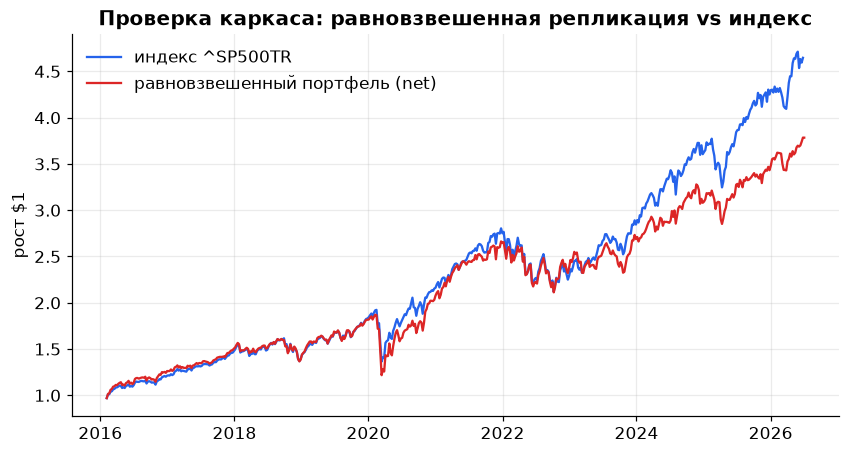

In [5]:
cum_port = (1 + res_ew.net).cumprod()
cum_idx = (1 + bench_returns.reindex(res_ew.net.index)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cum_idx.index, cum_idx.values, label="индекс ^SP500TR")
ax.plot(cum_port.index, cum_port.values, label="равновзвешенный портфель (net)")
ax.set_title("Проверка каркаса: равновзвешенная репликация vs индекс")
ax.set_ylabel("рост $1")
ax.legend()
plt.show()

Каркас работает: равновзвешенный портфель повторяет индекс с tracking error около 6.5% годовых и очень низким оборотом (веса почти не двигаются, поэтому net почти равен gross). Кумулятивно он идет рядом с индексом, но заметно отклоняется - это и есть та планка, которую умные методы должны пробить. Дальше подключаю первый настоящий метод: cap-weighted Top-K.

## Блок 4. Baseline: cap-weighted Top-K

Первый настоящий метод и заодно ориентир для всех следующих: беру K крупнейших по капитализации бумаг и взвешиваю их по капитализации. Это самая наивная разумная репликация индекса, и умные методы должны быть не хуже нее.

Капитализацию считаю тем самым приближением из первой тетради: `shares × price` на дату (текущее число акций, историческая цена). А чтобы вписать метод в контракт `method(доходности, индекс) -> веса`, специфичные для него аргументы (K, число акций, цены) я связываю через `partial`. То есть движок по-прежнему зовет `method(доходности_обучения, доходности_индекса)`, а K и данные метод уже знает.

Прогоню Top-K для K = 10, 30, 50 и посмотрю, как tracking error и turnover зависят от числа бумаг.

In [6]:
baselines = {}
print("cap-weighted Top-K (out-of-sample будет позже; пока весь период):")
for k in cfg.K_VALUES:
    m = partial(custom_cap_weighted_topk, k=k, shares=shares, prices=prices)
    r = custom_run_backtest(m, returns, bench_returns, membership,
                            train_weeks=cfg.TRAIN_WINDOW_WEEKS, cost_bps=cfg.TRANSACTION_COST_BPS)
    baselines[k] = r
    te = custom_tracking_error(r.net, bench_returns)
    print(f"  K={k:2d}: TE net {te:.2%} | turnover {r.turnover.mean():.1%}")

cap-weighted Top-K (out-of-sample будет позже; пока весь период):


  K=10: TE net 10.87% | turnover 3.7%


  K=30: TE net 6.07% | turnover 2.6%


  K=50: TE net 4.80% | turnover 2.4%


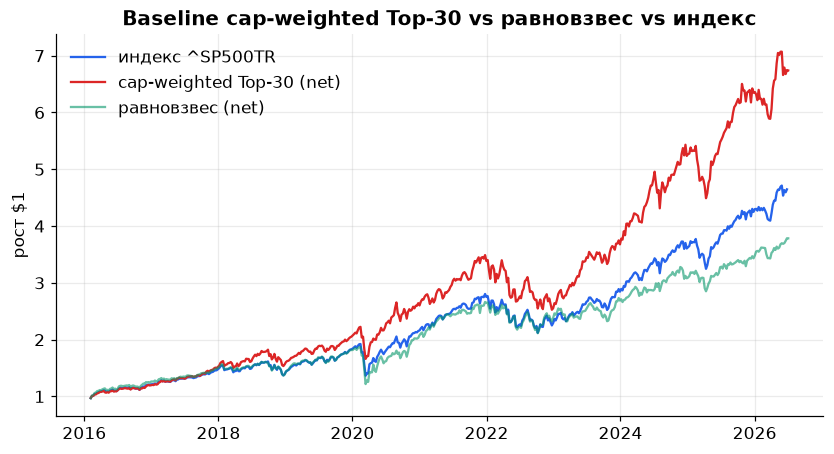

In [7]:
r30 = baselines[30]
idxc = (1 + bench_returns.reindex(r30.net.index)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(idxc.index, idxc.values, label="индекс ^SP500TR")
ax.plot(idxc.index, (1 + r30.net).cumprod().values, label="cap-weighted Top-30 (net)")
ax.plot(idxc.index, (1 + res_ew.net).cumprod().values, label="равновзвес (net)", alpha=0.6)
ax.set_title("Baseline cap-weighted Top-30 vs равновзвес vs индекс")
ax.set_ylabel("рост $1")
ax.legend()
plt.show()

Тут важный нюанс. По tracking error видно очевидное: чем больше K, тем точнее слежение (Top-50 уже точнее равновзвеса-всех), и turnover при этом скромный. Но посмотри на график: cap-weighted Top-30 не просто повторяет индекс, а заметно его обгоняет. Для трекинга это не победа, а отклонение: набрав только 30 крупнейших, я перевесил мега-техи, которые вырвались вперед, и портфель уехал вверх от индекса. Цель трекера не обогнать бенчмарк, а прижаться к нему, и именно это ловит tracking error. Так что cap-weighted Top-K это честная, но грубая планка. Дальше оптимизационные методы (LASSO, выпуклая min-TE) должны прижаться к индексу теснее: дать меньший tracking error при том же K.

## Блок 5. Методы трекинга: LASSO и выпуклая min-TE

Теперь два настоящих оптимизационных метода, оба под тот же контракт.

**LASSO (неотрицательный).** Регрессирую доходности индекса на доходности акций с L1-штрафом. L1 зануляет лишние бумаги, а я беру K с наибольшими коэффициентами и нормирую в сумму 1. Идея: пусть данные сами скажут, какие бумаги лучше всего объясняют индекс.

**Выпуклая min-TE (базовая версия).** Через `cvxpy` напрямую минимизирую tracking error. Сначала отбираю K бумаг, наиболее скоррелированных с индексом на обучающем окне, затем решаю `min ‖R·w − r‖²` при `w ≥ 0`, `Σw = 1`, то есть ищу оптимальные веса именно под минимум ошибки слежения. Пока без штрафа за turnover: это базовая версия, cost-aware сделаю следующим блоком.

Прогоню оба против baseline по всем K и сравню tracking error и turnover.

In [8]:
methods = {
    "baseline": lambda k: partial(custom_cap_weighted_topk, k=k, shares=shares, prices=prices),
    "LASSO": lambda k: partial(custom_lasso_tracking, k=k),
    "convex": lambda k: partial(custom_convex_tracking, k=k),
}
rows = []
for k in cfg.K_VALUES:
    for name, make in methods.items():
        r = custom_run_backtest(make(k), returns, bench_returns, membership,
                                train_weeks=cfg.TRAIN_WINDOW_WEEKS, cost_bps=cfg.TRANSACTION_COST_BPS)
        rows.append({"метод": name, "K": k,
                     "TE_net": custom_tracking_error(r.net, bench_returns),
                     "turnover": r.turnover.mean()})
comparison = pd.DataFrame(rows)
print("tracking error (net):")
print(comparison.pivot(index="K", columns="метод", values="TE_net").map(lambda x: f"{x:.2%}"))
print("\nсредний turnover:")
print(comparison.pivot(index="K", columns="метод", values="turnover").map(lambda x: f"{x:.1%}"))

tracking error (net):
метод  LASSO baseline convex
K                           
10     9.68%   10.87%  9.45%
30     7.43%    6.07%  7.27%
50     7.31%    4.80%  6.66%

средний turnover:
метод  LASSO baseline convex
K                           
10     53.6%     3.7%  43.1%
30     48.7%     2.6%  43.7%
50     47.3%     2.4%  43.0%


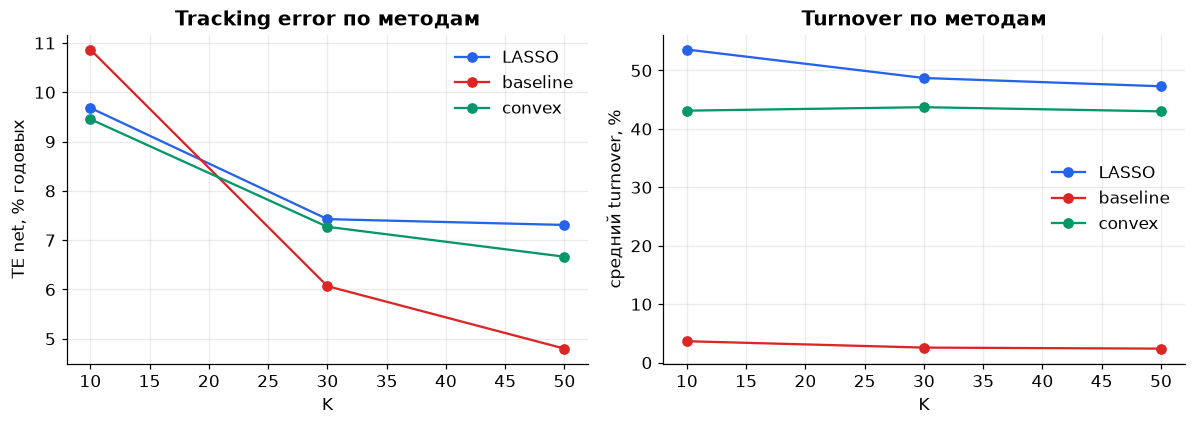

In [9]:
piv_te = comparison.pivot(index="K", columns="метод", values="TE_net")
piv_to = comparison.pivot(index="K", columns="метод", values="turnover")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for col in piv_te.columns:
    ax[0].plot(piv_te.index, piv_te[col] * 100, marker="o", label=col)
ax[0].set_title("Tracking error по методам"); ax[0].set_xlabel("K")
ax[0].set_ylabel("TE net, % годовых"); ax[0].legend()
for col in piv_to.columns:
    ax[1].plot(piv_to.index, piv_to[col] * 100, marker="o", label=col)
ax[1].set_title("Turnover по методам"); ax[1].set_xlabel("K")
ax[1].set_ylabel("средний turnover, %"); ax[1].legend()
fig.tight_layout(); plt.show()

Картина честная и поучительная. На малом K (10) оптимизация помогает: LASSO и выпуклый метод трекают точнее cap-weighted. Но на K = 30 и 50 baseline внезапно лучше по tracking error, а turnover у оптимизационных методов огромный - 40-50% против 2-4% у baseline. Причина классическая: методы подгоняют веса под прошлое окно и сильно перекладываются от ребаланса к ребалансу, то есть переобучаются и дорого торгуют. Стабильное cap-weighting этого не делает. Отсюда прямой следующий шаг: добавить штраф за turnover (cost-aware версия) - он должен и оборот сбить, и за счет стабильности улучшить слежение вне выборки.